In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce GTX 1650


In [3]:
def corrupt_image(img):

    def add_noise(i):
        return np.clip(i + np.random.normal(0,20,i.shape),0,255).astype(np.uint8)

    def blur(i):
        return cv2.GaussianBlur(i,(5,5),0)

    def lowres(i):
        h,w = i.shape[:2]
        small = cv2.resize(i,(w//3,h//3))
        return cv2.resize(small,(w,h))

    return random.choice([add_noise, blur, lowres])(img)

In [4]:
class RAImageDataset(Dataset):

    def __init__(self, root_dir, img_size=224):

        self.paths = [os.path.join(root_dir,f) for f in os.listdir(root_dir)]

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size,img_size))
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        corrupted = corrupt_image(img.copy())

        clean = self.transform(img)
        corrupted = self.transform(corrupted)

        return corrupted, clean

In [5]:
DATA_PATH = r"D:\Image Recognition\data"

dataset = RAImageDataset(DATA_PATH)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

print("Dataset size:", len(dataset))

Dataset size: 3000


In [6]:
class Block(nn.Module):

    def __init__(self,a,b):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(a,b,3,1,1),
            nn.BatchNorm2d(b),
            nn.ReLU()
        )

    def forward(self,x):
        return self.net(x)


class ProcessingNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            Block(3,64),
            Block(64,64),

            nn.MaxPool2d(2),

            Block(64,128),
            Block(128,128),

            nn.Upsample(scale_factor=2),

            Block(128,64),

            nn.Conv2d(64,3,3,1,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [7]:
model = ProcessingNet().to(device)

model.load_state_dict(
    torch.load("baseline_model.pth", map_location=device)
)

print("Baseline model loaded")

Baseline model loaded


In [8]:
teacher = models.resnet101(
    weights=models.ResNet101_Weights.DEFAULT
)

teacher = teacher.to(device)
teacher.eval()

print("ResNet101 teacher loaded")

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to C:\Users\VICTUS/.cache\torch\hub\checkpoints\resnet101-cd907fc2.pth


100%|██████████| 171M/171M [02:08<00:00, 1.39MB/s] 


ResNet101 teacher loaded


In [9]:
normalize = transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225]
)

In [10]:
image_loss = nn.MSELoss()
class_loss = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

lambda_recog = 0.1

In [11]:
EPOCHS = 10

for epoch in range(EPOCHS):

    epoch_loss = 0

    pbar = tqdm(loader)

    for corrupted, clean in pbar:

        corrupted = corrupted.to(device)
        clean = clean.to(device)

        restored = model(corrupted)

        img_loss = image_loss(restored, clean)

        with torch.no_grad():
            teacher_pred = teacher(normalize(clean))
            labels = teacher_pred.argmax(1)

        pred = teacher(normalize(restored))

        recog_loss = class_loss(pred, labels)

        loss = img_loss + lambda_recog * recog_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        pbar.set_postfix(
            img=img_loss.item(),
            cls=recog_loss.item(),
            total=loss.item()
        )

    print(f"Epoch {epoch+1} Loss: {epoch_loss/len(loader):.6f}")

100%|██████████| 375/375 [06:28<00:00,  1.04s/it, cls=0.997, img=0.00239, total=0.102] 


Epoch 1 Loss: 0.084110


100%|██████████| 375/375 [06:33<00:00,  1.05s/it, cls=0.329, img=0.00305, total=0.036] 


Epoch 2 Loss: 0.081795


100%|██████████| 375/375 [06:19<00:00,  1.01s/it, cls=0.962, img=0.00292, total=0.0991]


...

Epoch 8 Loss: 0.073161


100%|██████████| 375/375 [09:11<00:00,  1.47s/it, cls=0.361, img=0.0015, total=0.0376]  


Epoch 9 Loss: 0.074142


100%|██████████| 375/375 [09:43<00:00,  1.56s/it, cls=0.921, img=0.00239, total=0.0945] 

Epoch 10 Loss: 0.071074


In [12]:
torch.save(model.state_dict(),"RA_model_resnet101.pth")

print("RA ResNet101 model saved")

RA ResNet101 model saved


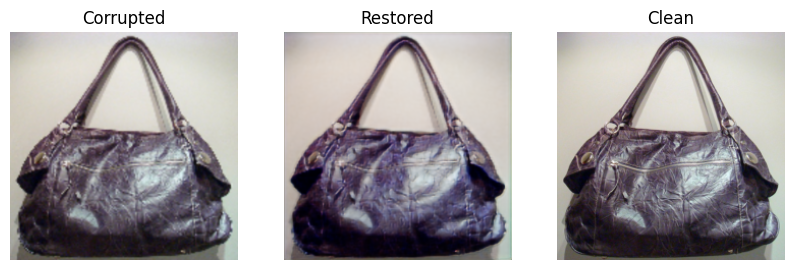

In [13]:
corrupted, clean = next(iter(loader))

corrupted = corrupted.to(device)

with torch.no_grad():
    restored = model(corrupted).cpu()

def show(img):
    img = img.permute(1,2,0).numpy()
    img = np.clip(img,0,1)
    plt.imshow(img)
    plt.axis("off")

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
show(corrupted[0].cpu())
plt.title("Corrupted")

plt.subplot(1,3,2)
show(restored[0])
plt.title("Restored")

plt.subplot(1,3,3)
show(clean[0])
plt.title("Clean")

plt.show() 